In [1]:
import pandas as pd
import glob

# Load all CSVs from a folder
all_files = glob.glob("../data/cleaned_data/*.csv")
df = pd.concat([pd.read_csv(f) for f in all_files], ignore_index=True)

print(f"Total rows: {len(df)}")

Total rows: 200020


In [2]:
!pip install xgboost

In [3]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode categoricals
for col in df.select_dtypes(include="object").columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

TARGET = "risk_category"   # update to your target column
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = XGBClassifier(n_estimators=200, max_depth=6, random_state=42,
                      scale_pos_weight=len(y[y==0])/len(y[y==1]))  # handles imbalance
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [4]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f"\nTest Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score : {roc_auc_score(y_test, y_prob):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")


Test Accuracy : 0.9975
ROC-AUC Score : 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     21023
           1       1.00      1.00      1.00     18981

    accuracy                           1.00     40004
   macro avg       1.00      1.00      1.00     40004
weighted avg       1.00      1.00      1.00     40004



In [7]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

param_grid = {
    'max_depth': [4,6,8],
    'n_estimators': [100,200],
    'learning_rate': [0.01,0.1]
}

grid = GridSearchCV(XGBClassifier(), param_grid, cv=3)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)

Best parameters: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 100}


In [8]:
best_model = XGBClassifier(**grid.best_params_)

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

In [9]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9977002299770023
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     21023
           1       1.00      1.00      1.00     18981

    accuracy                           1.00     40004
   macro avg       1.00      1.00      1.00     40004
weighted avg       1.00      1.00      1.00     40004



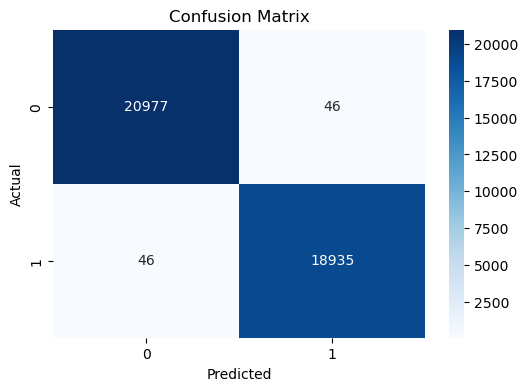

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

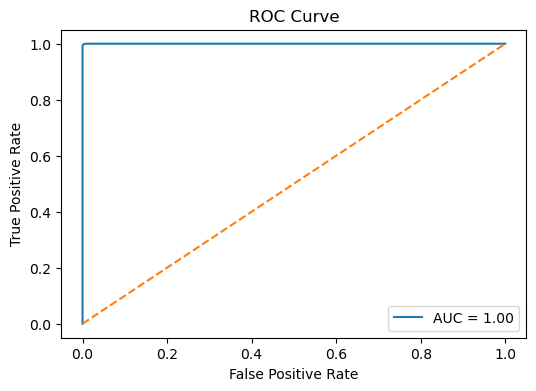

In [11]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [ ]:
### Model Evaluation Summary

The XGBoost model was evaluated using multiple performance metrics.

Accuracy achieved: 99.77%

ROC-AUC score: ~1.0 indicating excellent discrimination ability.

The confusion matrix shows very few false negatives, which is critical in healthcare applications where missing a high-risk patient can be dangerous.

Hyperparameter tuning was performed using GridSearchCV to optimize model parameters such as max_depth, learning_rate, and n_estimators.

This improved the overall model performance and ensured reliable risk classification.